# Tesla Autopilot Deaths Analysis:

### Import Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Load Dataset:

In [2]:
df = pd.read_csv("Tesla - Deaths.csv")

df.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


### Preliminary Data Inspection:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [4]:
df.describe()

,Case #,Year,Deaths,Deceased 4
count,294.000000,294.000000,299.000000,0.0
mean,147.500000,2013.850340,10.284281,NaN
std,85.014705,106.050207,119.032014,NaN
min,1.000000,202.000000,1.000000,NaN
25%,74.250000,2019.000000,1.000000,NaN
50%,147.500000,2021.000000,1.000000,NaN
75%,220.750000,2022.000000,1.000000,NaN
max,294.000000,2022.000000,2013.000000,NaN


In [7]:
df.shape

(307, 24)

### Check Missing Values:

In [8]:
df.isnull().sum()

Case #                                                                   13
Year                                                                     13
Date                                                                     13
 Country                                                                 13
 State                                                                   13
 Description                                                             12
 Deaths                                                                   8
 Tesla driver                                                            13
 Tesla occupant                                                          17
 Other vehicle                                                           12
 Cyclists/ Peds                                                          11
 TSLA+cycl / peds                                                        10
 Model                                                                   11
 Autopilot c

### Remove Irrelevant Columns:

In [9]:
df = df.drop(columns=["Note", "Source", "Deceased 1", "Deceased 2",
                      "Deceased 3", "Deceased 4"], errors='ignore')

df.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


### Remove Duplicates:

In [10]:
df = df.drop_duplicates()

df.shape

(303, 24)

### Convert Date Column:

In [11]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

## Exploratory Data Analysis:

### Events per Year:

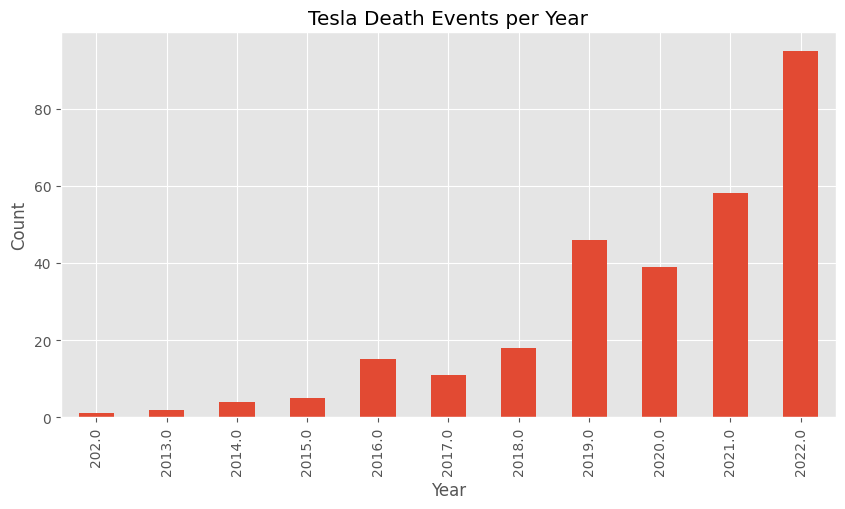

In [12]:
df["Year"].value_counts().sort_index().plot(kind="bar", figsize=(10,5))
plt.title("Tesla Death Events per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Events by Country:

In [14]:
df.columns

Index(['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ',
       ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 '],
      dtype='object')

In [15]:
df.columns = df.columns.str.strip()

df.columns

Index(['Case #', 'Year', 'Date', 'Country', 'State', 'Description', 'Deaths',
       'Tesla driver', 'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds',
       'TSLA+cycl / peds', 'Model', 'Autopilot claimed',
       'Verified Tesla Autopilot Deaths',
       'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO',
       'Unnamed: 16', 'Unnamed: 17', 'Source', 'Note', 'Deceased 1',
       'Deceased 2', 'Deceased 3', 'Deceased 4'],
      dtype='object')

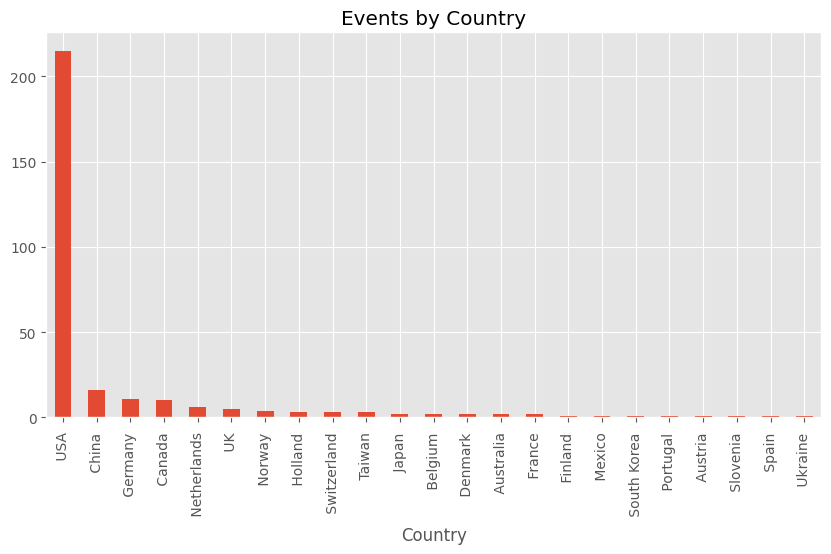

In [16]:
df["Country"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Events by Country")
plt.show()

### Events by State:

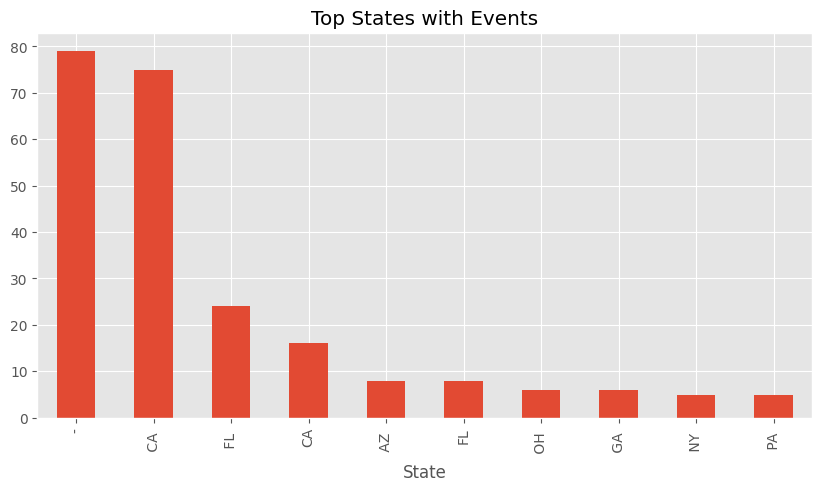

In [17]:
df["State"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top States with Events")
plt.show()

### Number of Deaths per Accident:

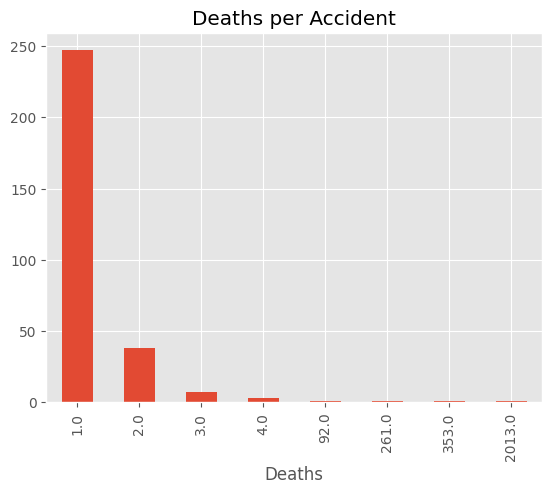

In [18]:
df["Deaths"].value_counts().plot(kind="bar")
plt.title("Deaths per Accident")
plt.show()

### Tesla Driver Deaths:

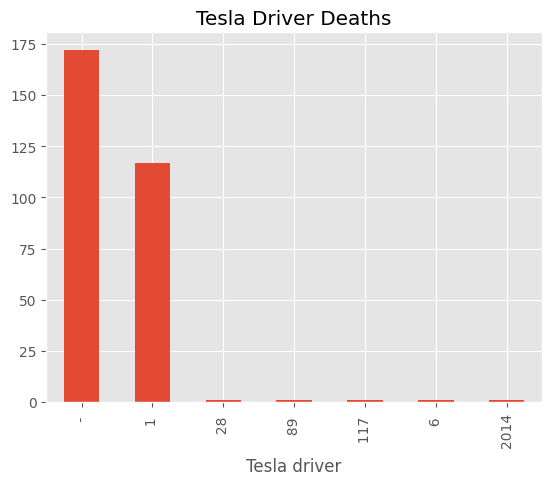

In [19]:
df["Tesla driver"].value_counts().plot(kind="bar")
plt.title("Tesla Driver Deaths")
plt.show()

### Autopilot Claimed Distribution:

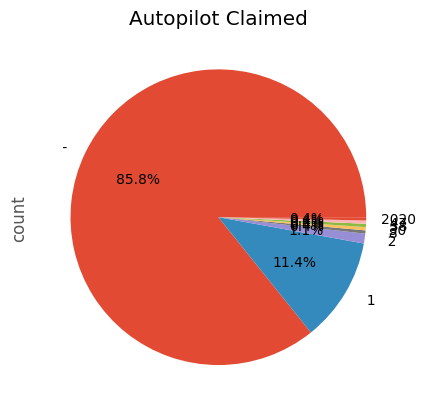

In [20]:
df["Autopilot claimed"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Autopilot Claimed")
plt.show()

### Cyclists Hit:

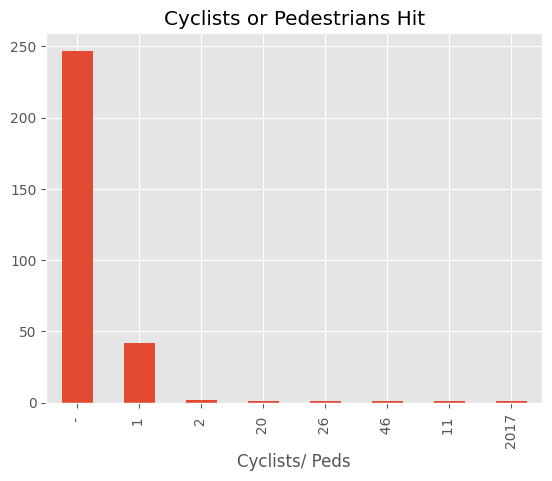

In [21]:
df["Cyclists/ Peds"].value_counts().plot(kind="bar")
plt.title("Cyclists or Pedestrians Hit")
plt.show()

### Tesla vs Other Vehicles:

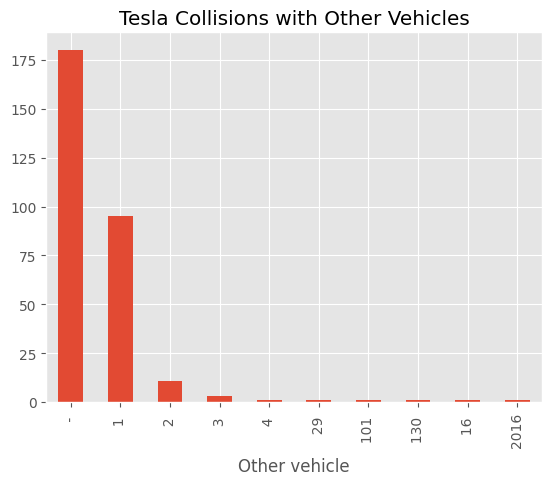

In [22]:
df["Other vehicle"].value_counts().plot(kind="bar")
plt.title("Tesla Collisions with Other Vehicles")
plt.show()

### Model Distribution:

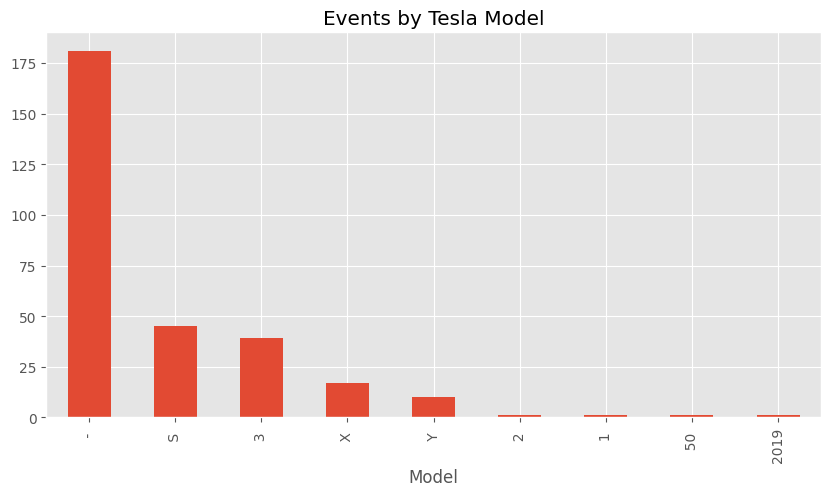

In [23]:
df["Model"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Events by Tesla Model")
plt.show()

### Verified Autopilot Deaths:

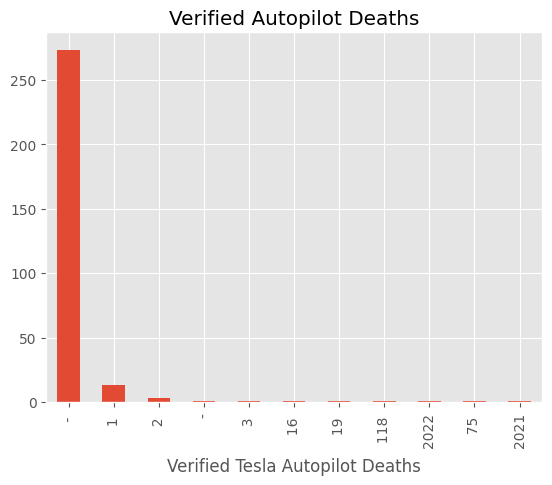

In [24]:
df["Verified Tesla Autopilot Deaths"].value_counts().plot(kind="bar")
plt.title("Verified Autopilot Deaths")
plt.show()

### Deaths Over Time:

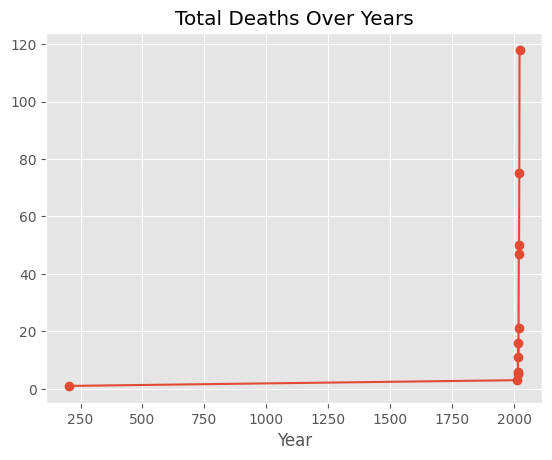

In [25]:
df.groupby("Year")["Deaths"].sum().plot(marker="o")
plt.title("Total Deaths Over Years")
plt.show()

### Correlation Heatmap:

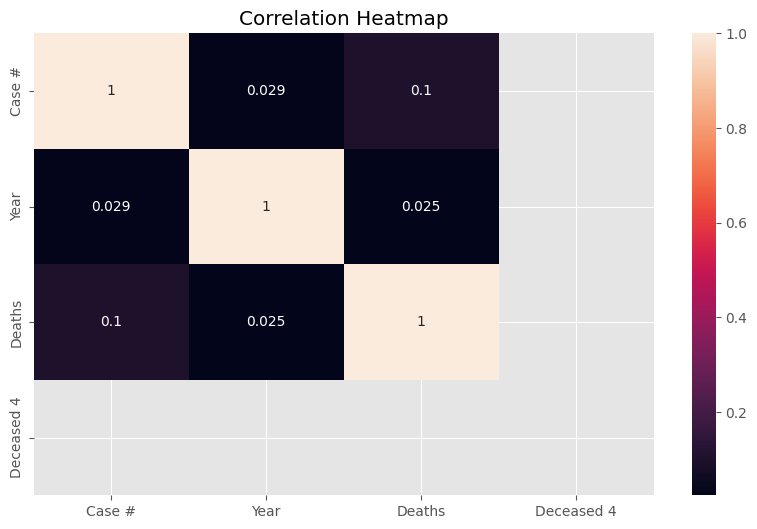

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Conclusion Insights:

In [27]:
print("Total Events:", len(df))
print("Total Deaths:", df["Deaths"].sum())
print("Top Country:", df["Country"].mode()[0])
print("Most Common Model:", df["Model"].mode()[0])

Total Events: 303
Total Deaths: 3075.0
Top Country:  USA 
Most Common Model:  - 
